<a href="https://colab.research.google.com/github/dhag/colab_demo/blob/main/%E5%BC%B7%E5%8C%96%E5%AD%A6%E7%BF%92%E3%81%AB%E3%82%88%E3%82%8B%E5%80%92%E7%AB%8B%E6%8C%AF%E5%AD%90_%E6%94%B9%E8%89%AF%E7%89%88.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

強化学習　倒立振子　カートポール　CartPole

台車の上に棒（倒立振り子）を立てて台車を左右に動かすことによって棒が倒れないように制御する。人間やヒト型ロボットが立っているの状態もこれ。写真は<倒立振子 - Wikipedia>



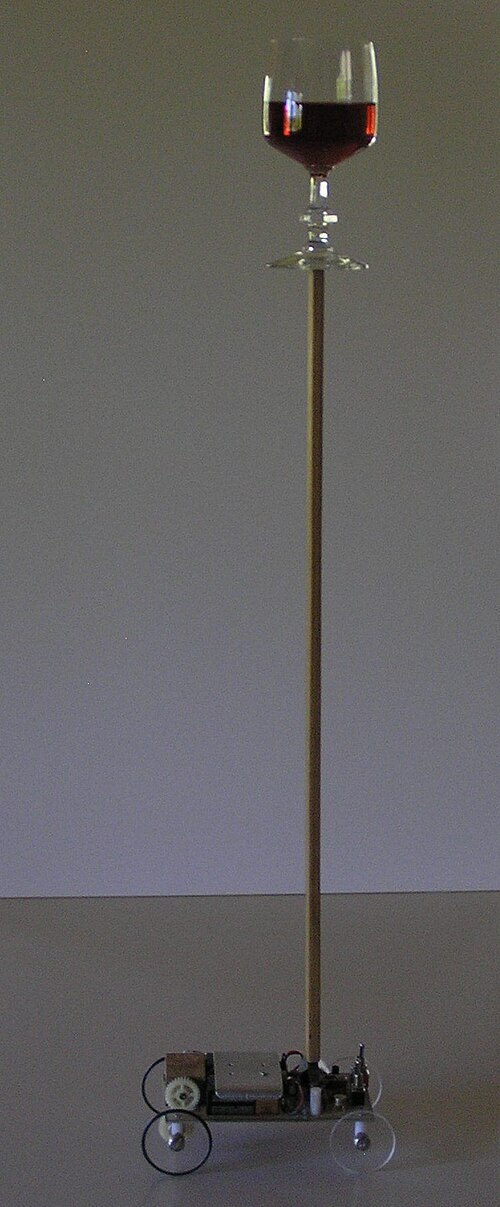

参考サイト

https://colab.research.google.com/github/YutaroOgawa/pytorch_tutorials_jp/blob/main/notebook/4_RL/4_1_reinforcement_q_learning_jp.ipynb


ランタイムのタイプをGPUにしておくのがおすすめ

In [3]:
# 必要なパッケージのインストール
!pip install gymnasium[other]  # render_modeサポート含む
#!pip install matplotlib
#!pip install torch torchvision
!pip install opencv-python     # 動画処理用
!pip install base64            # 動画エンコード用
!pip install ipython          # Jupyter/Colab表示用

ERROR: Could not find a version that satisfies the requirement base64 (from versions: none)
ERROR: No matching distribution found for base64


## 日本語フォントの設定（グラフの「豆腐(□)」対策）

Colab の matplotlib は初期状態で日本語フォントを持たないため、グラフのタイトル・軸ラベル・凡例が □ になります。
**最初に必ず次のセルを実行**してください（japanize-matplotlib → IPAexGothic → Noto CJK の順に自動で設定します）。


日本語フォント: /usr/share/fonts/opentype/ipaexfont-gothic/ipaexg.ttf を使用


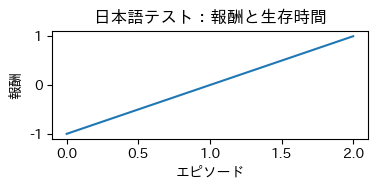

In [4]:
# ============================================================
# 日本語フォント設定 : matplotlib の文字化け(豆腐 □)対策
#   グラフ中の日本語(タイトル・軸ラベル・凡例)が □ になるのを防ぐ。
#   Colab では既定フォントに日本語が無いため、毎回これを実行する。
# ============================================================
import matplotlib
import matplotlib.pyplot as plt

def setup_japanese_font():
    # 方法1: japanize-matplotlib があれば最優先(import するだけで設定完了)
    try:
        import japanize_matplotlib  # noqa: F401
        print("日本語フォント: japanize-matplotlib を使用")
        return
    except Exception:
        pass
    # 方法2: IPAexGothic を入れて登録(Colab で確実)
    import os, subprocess, matplotlib.font_manager as fm
    candidates = [
        "/usr/share/fonts/opentype/ipaexfont-gothic/ipaexg.ttf",
        "/usr/share/fonts/truetype/fonts-japanese-gothic.ttf",
    ]
    if not any(os.path.exists(p) for p in candidates):
        subprocess.run("apt-get -qq -y install fonts-ipaexfont", shell=True,
                       stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    for p in candidates:
        if os.path.exists(p):
            fm.fontManager.addfont(p)
            matplotlib.rc("font", family=fm.FontProperties(fname=p).get_name())
            print(f"日本語フォント: {p} を使用")
            break
    else:
        # 方法3: Noto CJK にフォールバック
        matplotlib.rc("font", family="Noto Sans CJK JP")
        print("日本語フォント: Noto Sans CJK JP を使用")

setup_japanese_font()
plt.rcParams["axes.unicode_minus"] = False   # マイナス記号の豆腐も防ぐ

# 動作確認(□ にならなければ成功)
plt.figure(figsize=(4, 2))
plt.title("日本語テスト：報酬と生存時間")
plt.xlabel("エピソード"); plt.ylabel("報酬")
plt.plot([0, 1, 2], [-1, 0, 1]); plt.tight_layout(); plt.show()




---



# 基本的な実験

とりあえず動かしてみる。動画が生成されるのでダウンロードしてみてみる。

人工知能による解説

🎯 CartPoleの行動空間の仕組み
CartPoleの行動は{0, 1}の2つの離散値のみで、それぞれ固定の力の方向を意味します：

行動0: 左方向に固定の力を加える
行動1: 右方向に固定の力を加える DDPG-CARTPOLE/cartpole_env.py at master · Yuantian013/DDPG-CARTPOLE

💪 力の計算方法
ソースコードから見ると：
python# CartPoleのstep関数内
force = self.force_mag if action == 1 else -self.force_mag
つまり、force_mag（デフォルト10.0N）という固定の力の大きさが、行動に応じて+10N（右）または-10N（左）として適用されます。
🔄 ON/OFF制御の特徴

力の大きさは一定: force_mag = 10.0で固定
方向のみ制御: 行動によって力の向きだけが変わる
連続制御ではない: 微細な力調整はできない

🆚 連続制御との比較
一方、連続制御版のCartPoleも存在し、この場合の行動空間は[-1, 1]の連続値となり、より細かい力制御が可能になります。 ReadthedocsReadthedocs
🧠 なぜON/OFF制御なのか？

学習の簡単さ: 離散行動は連続行動より学習が容易
現実的な制約: 実際のロボット制御でもON/OFF制御は一般的
ベンチマーク目的: 強化学習アルゴリズムの性能比較に適している

あなたのコードでforce_magを変更することで、この「固定の力の大きさ」を調整し、学習への影響を比較していたということですね！この設計により、エージェントは「いつ」力を加えるかのタイミング学習に集中でき、力の大きさ調整という複雑さを排除できています。

使用デバイス: cuda
=== DQN学習比較実験 ===
目標: 学習が最も効率的に進む力の大きさを見つける


力の大きさ 10.0 での訓練
力の大きさ 10.0 で学習開始...
  ウォームアップ期間...
  本格的な学習開始...
  エピソード 0: 平均報酬 = 12.00, ε = 0.951
  エピソード 50: 平均報酬 = 33.84, ε = 0.077
  エピソード 100: 平均報酬 = 50.85, ε = 0.010
  エピソード 150: 平均報酬 = 126.83, ε = 0.010
  エピソード 200: 平均報酬 = 257.03, ε = 0.010
  エピソード 250: 平均報酬 = 343.02, ε = 0.010
  エピソード 300: 平均報酬 = 363.39, ε = 0.010
  エピソード 350: 平均報酬 = 405.67, ε = 0.010
  エピソード 400: 平均報酬 = 402.33, ε = 0.010
  エピソード 450: 平均報酬 = 368.18, ε = 0.010
  エピソード 500: 平均報酬 = 378.33, ε = 0.010
  エピソード 550: 平均報酬 = 343.52, ε = 0.010
  エピソード 600: 平均報酬 = 301.09, ε = 0.010
  エピソード 650: 平均報酬 = 285.83, ε = 0.010
  エピソード 700: 平均報酬 = 276.94, ε = 0.010
  エピソード 750: 平均報酬 = 275.63, ε = 0.010
  エピソード 800: 平均報酬 = 281.15, ε = 0.010
  エピソード 850: 平均報酬 = 282.39, ε = 0.010
  エピソード 900: 平均報酬 = 281.80, ε = 0.010
  エピソード 950: 平均報酬 = 311.63, ε = 0.010
  最終平均報酬: 337.20
  力の大きさ 10.0 の動画記録中...


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /content/videos/force_10.0 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


    エピソード 1: 報酬 = 500.0, ステップ数 = 500


/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


    エピソード 2: 報酬 = 323.0, ステップ数 = 323
    エピソード 3: 報酬 = 500.0, ステップ数 = 500
  動画保存完了: ./videos/force_10.0/ (平均報酬: 441.00)
    生成された動画: force-10.0-episode-2.mp4 (サイズ: 27530 バイト)
    生成された動画: force-10.0-episode-0.mp4 (サイズ: 31500 バイト)
    生成された動画: force-10.0-episode-1.mp4 (サイズ: 24931 バイト)

力の大きさ 20.0 での訓練
力の大きさ 20.0 で学習開始...
  ウォームアップ期間...
  本格的な学習開始...
  エピソード 0: 平均報酬 = 38.00, ε = 0.951
  エピソード 50: 平均報酬 = 15.80, ε = 0.077
  エピソード 100: 平均報酬 = 35.47, ε = 0.010
  エピソード 150: 平均報酬 = 164.57, ε = 0.010
  エピソード 200: 平均報酬 = 273.15, ε = 0.010
  エピソード 250: 平均報酬 = 311.93, ε = 0.010
  エピソード 300: 平均報酬 = 329.94, ε = 0.010
  エピソード 350: 平均報酬 = 279.09, ε = 0.010
  エピソード 400: 平均報酬 = 277.06, ε = 0.010
  エピソード 450: 平均報酬 = 315.72, ε = 0.010
  エピソード 500: 平均報酬 = 314.22, ε = 0.010
  エピソード 550: 平均報酬 = 298.42, ε = 0.010
  エピソード 600: 平均報酬 = 261.08, ε = 0.010
  エピソード 650: 平均報酬 = 283.24, ε = 0.010
  エピソード 700: 平均報酬 = 337.66, ε = 0.010
  エピソード 750: 平均報酬 = 346.66, ε = 0.010
  エピソード 800: 平均報酬 = 380.14, ε = 0.010
  エピソード 8

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /content/videos/force_20.0 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


    エピソード 1: 報酬 = 338.0, ステップ数 = 338
    エピソード 2: 報酬 = 366.0, ステップ数 = 366
    エピソード 3: 報酬 = 454.0, ステップ数 = 454
  動画保存完了: ./videos/force_20.0/ (平均報酬: 386.00)
    生成された動画: force-20.0-episode-0.mp4 (サイズ: 25756 バイト)
    生成された動画: force-20.0-episode-1.mp4 (サイズ: 27953 バイト)
    生成された動画: force-20.0-episode-2.mp4 (サイズ: 32289 バイト)

力の大きさ 30.0 での訓練
力の大きさ 30.0 で学習開始...
  ウォームアップ期間...
  本格的な学習開始...
  エピソード 0: 平均報酬 = 12.00, ε = 0.951
  エピソード 50: 平均報酬 = 18.53, ε = 0.077
  エピソード 100: 平均報酬 = 27.94, ε = 0.010
  エピソード 150: 平均報酬 = 112.25, ε = 0.010
  エピソード 200: 平均報酬 = 260.10, ε = 0.010
  エピソード 250: 平均報酬 = 352.24, ε = 0.010
  エピソード 300: 平均報酬 = 391.97, ε = 0.010
  エピソード 350: 平均報酬 = 390.91, ε = 0.010
  エピソード 400: 平均報酬 = 350.78, ε = 0.010
  エピソード 450: 平均報酬 = 335.37, ε = 0.010
  エピソード 500: 平均報酬 = 341.23, ε = 0.010
  エピソード 550: 平均報酬 = 318.87, ε = 0.010
  エピソード 600: 平均報酬 = 309.11, ε = 0.010
  エピソード 650: 平均報酬 = 311.54, ε = 0.010
  エピソード 700: 平均報酬 = 295.07, ε = 0.010
  エピソード 750: 平均報酬 = 316.27, ε = 0.010
  エピソード 80

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /content/videos/force_30.0 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


    エピソード 1: 報酬 = 299.0, ステップ数 = 299
    エピソード 2: 報酬 = 324.0, ステップ数 = 324
    エピソード 3: 報酬 = 335.0, ステップ数 = 335
  動画保存完了: ./videos/force_30.0/ (平均報酬: 319.33)
    生成された動画: force-30.0-episode-1.mp4 (サイズ: 25958 バイト)
    生成された動画: force-30.0-episode-2.mp4 (サイズ: 26341 バイト)
    生成された動画: force-30.0-episode-0.mp4 (サイズ: 23667 バイト)
結果を dqn_results.csv に保存しました


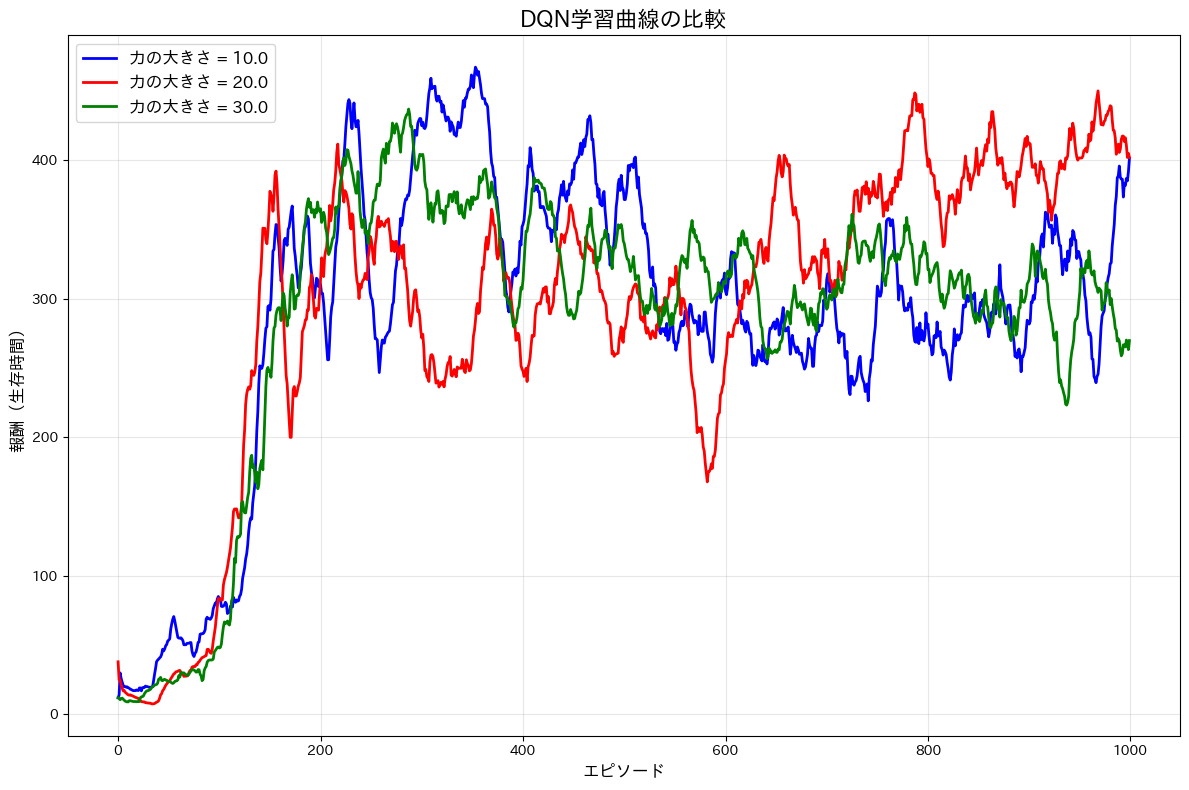


=== 最終性能の比較 ===
力の大きさ 10.0: 最終平均報酬 = 339.06
                  動画テスト平均報酬 = 441.00
力の大きさ 20.0: 最終平均報酬 = 425.18
                  動画テスト平均報酬 = 386.00
力の大きさ 30.0: 最終平均報酬 = 288.46
                  動画テスト平均報酬 = 319.33

=== 録画された動画の表示 ===

力の大きさ 10.0 の動画:
動画ファイル: ./videos/force_10.0/force-10.0-episode-2.mp4 (サイズ: 27530 バイト)

力の大きさ 20.0 の動画:
動画ファイル: ./videos/force_20.0/force-20.0-episode-2.mp4 (サイズ: 32289 バイト)

力の大きさ 30.0 の動画:
動画ファイル: ./videos/force_30.0/force-30.0-episode-2.mp4 (サイズ: 26341 バイト)

=== 考察のポイント ===
1. どの力の大きさが最も早く学習しましたか？
2. どの力の大きさが最も高い最終性能を達成しましたか？
3. 力が大きすぎる/小さすぎる場合、学習にどのような影響がありましたか？
4. あなたの考える「最適な」力の大きさはいくつですか？その理由は？
dqn_results.csv から結果を読み込みました

保存されたデータの形状: (3000, 4)
力の大きさの種類: [10. 20. 30.]
各設定でのエピソード数: [1000 1000 1000]


In [5]:
# ============================================================================
# 【このセル = DQN 本体】  スライド ⑪〜⑲ に対応
#   1つのセルに「DQN の全部品」が詰まっている。スライドの部品名と対応づけて読む:
#     ・class DQN          → Q表の代わり(Q関数をNNで近似)         … スライド ⑬
#     ・class ReplayBuffer  → 経験再生(Experience Replay)          … スライド ⑭
#     ・DQNAgent.act        → ε-greedy で行動選択                  … スライド ⑩
#     ・DQNAgent.replay     → ★ベルマン更新の本体(損失=TD誤差)     … スライド ⑮
#     ・FastCartPoleEnv     → ★環境 = 遷移確率 P の在り処          … スライド ⑯
#     ・train_dqn_agent     → 学習ループ + 報酬 r の設計           … スライド ⑰⑱⑲
# ============================================================================
# DQN実習用コード（スリム化版）
import os
import glob
import base64
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
import random
from collections import deque
import matplotlib.pyplot as plt
from IPython.display import HTML

# デバイスの設定
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用デバイス: {device}")

# ============================================================================
# DQNネットワークの定義
# ============================================================================
# ----------------------------------------------------------------------------
# ■ スライド ⑬:  class DQN = 「Q表」の代わり
#   教科書では Q(s,a) を表で持つが、状態が連続なので表は作れない(行が無限)。
#   そこで状態(4次元)を入力 → 各行動のQ値(2個)を出力する NN で近似する。
#   入力4 → 256 → 256 → 出力2。 学習対象は重み θ。
# ----------------------------------------------------------------------------
class DQN(nn.Module):
    """Deep Q-Network: 状態から行動価値を予測するニューラルネットワーク"""
    def __init__(self, state_size, action_size, hidden_size=128):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, action_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)  # 出力 = [Q(s, a=0), Q(s, a=1)] : 各行動の価値

# ============================================================================
# 経験リプレイバッファ
# ============================================================================
# ----------------------------------------------------------------------------
# ■ スライド ⑭:  class ReplayBuffer = 経験再生(Experience Replay)
#   経験 (s, a, r, s', done) を貯め、ランダムに取り出して学習する。
#   連続した経験は強く相関するため、そのまま学習すると偏って不安定。
#   ランダム抽出で相関を断ち、学習を安定させる。
#   ★この1件1件が「遷移確率 P のサンプル」。表の代わりに、経験の山が P を表す。
# ----------------------------------------------------------------------------
class ReplayBuffer:
    """過去の経験を蓄積し、ランダムサンプリングで学習に使用"""
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        """経験をバッファに追加"""
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        """バッファからランダムにサンプル"""
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = map(np.stack, zip(*batch))
        return state, action, reward, next_state, done

    def __len__(self):
        return len(self.buffer)

# ============================================================================
# DQNエージェント
# ============================================================================
# ----------------------------------------------------------------------------
# ■ DQNエージェント : 行動選択(act)と学習(replay)を担う本体
#   主なハイパーパラメータ(スライド ⑩):
#     epsilon 系 → ε-greedy の探索率 / gamma → 割引率 γ / target_update → θ⁻ の同期頻度
#   policy_net = 主ネット(θ, 学習中) , target_net = ターゲットネット(θ⁻, 固定して時々同期)
# ----------------------------------------------------------------------------
class DQNAgent:
    """DQN学習アルゴリズムを実装するエージェント"""
    def __init__(self, state_size, action_size, lr=5e-4):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = ReplayBuffer(50000)

        # ε-greedy戦略のパラメータ
        self.epsilon = 1.0          # 初期探索率
        self.epsilon_min = 0.01     # 最小探索率　# 0.01から0.05に変更
        self.epsilon_decay = 0.99   # 探索率の減衰

        # 学習パラメータ
        self.learning_rate = lr
        self.batch_size = 64
        self.target_update = 5      # ターゲットネットワーク更新頻度# 5から10に変更
        self.gamma = 0.99           # 割引率

        # ニューラルネットワークの初期化
        self.policy_net = DQN(state_size, action_size, hidden_size=256).to(device)
        self.target_net = DQN(state_size, action_size, hidden_size=256).to(device)
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)

        # ターゲットネットワークの初期化
        self.update_target_network()

    def update_target_network(self):
        """ターゲットネットワークを主ネットワークの重みで更新"""
        self.target_net.load_state_dict(self.policy_net.state_dict())

    def remember(self, state, action, reward, next_state, done):
        """経験をメモリに保存"""
        self.memory.push(state, action, reward, next_state, done)

    # ------------------------------------------------------------------------
    # ■ スライド ⑩:  ε-greedy で行動を選ぶ(探索と活用)
    #   確率 ε でランダム行動(探索) / それ以外は Q値が最大の行動(活用)。
    # ------------------------------------------------------------------------
    def act(self, state):
        """ε-greedy戦略で行動を選択"""
        if np.random.random() <= self.epsilon:
            return random.randrange(self.action_size)  # 探索

        # 最適行動を選択
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        q_values = self.policy_net(state_tensor)
        return np.argmax(q_values.cpu().data.numpy())

    # ------------------------------------------------------------------------
    # ■ スライド ⑮ ★最重要:  replay() = ベルマン更新の本体
    #   スライド ⑧⑨ の損失式
    #       L(θ) = ( r + γ·max_a' Q(s',a'; θ⁻)  −  Q(s,a; θ) )^2
    #   を、バッファのバッチ(64件)から最小二乗で最小化する。表は一切使わない。
    # ------------------------------------------------------------------------
    def replay(self):
        """経験リプレイによる学習"""
        if len(self.memory) < self.batch_size:
            return

        # バッチサンプリング
        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)

        # テンソルに変換
        states = torch.FloatTensor(states).to(device)
        actions = torch.LongTensor(actions).to(device)
        rewards = torch.FloatTensor(rewards).to(device)
        next_states = torch.FloatTensor(next_states).to(device)
        dones = torch.BoolTensor(dones).to(device)

        # Q値の計算
        current_q_values = self.policy_net(states).gather(1, actions.unsqueeze(1))  # Q(s,a; θ): 現在の見積り
        next_q_values = self.target_net(next_states).max(1)[0].detach()  # max_a' Q(s',a'; θ⁻): θ⁻で次状態を評価
        target_q_values = rewards + (self.gamma * next_q_values * ~dones)  # r + γ·maxQ = TDターゲット(目標値)

        # 損失計算とバックプロパゲーション
        loss = F.mse_loss(current_q_values.squeeze(), target_q_values)  # (目標 − 現在)^2 = TD誤差

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 1.0)
        self.optimizer.step()

        # 探索率の更新
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

# ============================================================================
# カスタムCartPole環境
# ============================================================================
# ----------------------------------------------------------------------------
# ■ スライド ⑯ ★核心:  FastCartPoleEnv (env.step()) = 遷移確率 P の在り処
#   「次状態 s' がどう決まるか」 P(s'|s,a) は、表ではなく gym 内部の物理計算が担う。
#   エージェントは P を知らない。step() を呼び、結果 (s', r) をサンプルとして受け取るだけ。
#   = モデルフリー強化学習。 (force_mag = 加える力の大きさ。向きは行動で決まる)
# ----------------------------------------------------------------------------
class FastCartPoleEnv(gym.Wrapper):
    """力の大きさを調整可能なCartPole環境"""
    def __init__(self, force_mag=10.0, render_mode=None):
        env = gym.make('CartPole-v1', render_mode=render_mode)
        super().__init__(env)
        self.force_mag = force_mag

    def step(self, action):
        self.env.unwrapped.force_mag = self.force_mag
        return super().step(action)

# ============================================================================
# 学習関数
# ============================================================================
def train_dqn_agent(force_mag=10.0, episodes=500):
    """指定された力の大きさでDQNエージェントを訓練"""
    print(f"力の大きさ {force_mag} で学習開始...")

    env = FastCartPoleEnv(force_mag=force_mag)
    state_size = env.observation_space.shape[0]
    action_size = env.action_space.n

    agent = DQNAgent(state_size, action_size)
    scores = []
    scores_window = deque(maxlen=100)

    # ウォームアップ期間（ランダム行動で経験を蓄積）
    print("  ウォームアップ期間...")
    for warmup_ep in range(50):
        state, _ = env.reset()
        for step in range(200):
            action = env.action_space.sample()
            next_state, reward, done, truncated, _ = env.step(action)
            agent.remember(state, action, reward, next_state, done)
            state = next_state
            if done or truncated:
                break

    print("  本格的な学習開始...")

    for episode in range(episodes):
        state, _ = env.reset()
        total_reward = 0

        for step in range(1000):
            action = agent.act(state)
            next_state, reward, done, truncated, _ = env.step(action)

            # ----------------------------------------------------------------
            # ■ スライド ⑱:  報酬 r の設計(報酬シェイピング)
            #   標準CartPoleの報酬は「生存中 = +1」。ここではそれを上書きして、
            #   終端で大きな賞罰を与え、学習を加速する:
            #     早く倒れた(step<200) → -10 (損)   /   長く生存 → +10 (得)
            #   ※この reward が「学習に使う信号」。次の total_reward とは別物(下の注記)。
            # ----------------------------------------------------------------
            # 報酬の調整
            if done or truncated:
                if step < 200:
                    reward = -10  # 早期終了にペナルティ
                else:
                    reward = 10   # 長時間生存にボーナス

            agent.remember(state, action, reward, next_state, done)
            state = next_state
            # ★スライド ⑲:  「報酬」と「スコア」は別物
            #   total_reward は生存ステップ数(= 評価用スコア, グラフの縦軸)。
            #   学習に使う報酬(上の reward, ±10) とは目的が違う別の量。
            total_reward += 1  # スコア = 生存時間(ステップ数)

            if done or truncated:
                break

        scores.append(total_reward)
        scores_window.append(total_reward)

        # 学習実行
        if len(agent.memory) > agent.batch_size:
            for _ in range(5):
                agent.replay()

        # ターゲットネットワーク更新
        if episode % agent.target_update == 0:
            agent.update_target_network()

        # 進捗表示
        if episode % 50 == 0:
            avg_score = np.mean(scores_window)
            print(f"  エピソード {episode}: 平均報酬 = {avg_score:.2f}, ε = {agent.epsilon:.3f}")

        # 👈 性能低下検出
        if len(scores_window) >= 100:
            # dequeをリストに変換してスライス操作を可能にする
            recent_scores = list(scores_window)[-30:]  # 最近30エピソード
            if len(recent_scores) >= 30:
                recent_10 = np.mean(recent_scores[-10:])    # 最新10エピソードの平均
                previous_10 = np.mean(recent_scores[-20:-10])  # その前10エピソードの平均
                #if recent_10 < previous_10 * 0.95:  # 5%以上の性能低下
                    #print(f"  エピソード {episode} で性能低下により早期停止")
                    #print(f"  最新10ep平均: {recent_10:.2f}, 前10ep平均: {previous_10:.2f}")
                    #break

        # 早期停止条件
        if len(scores_window) == 100 and np.mean(scores_window) >= 450:
            print(f"  エピソード {episode} で目標達成！平均報酬: {np.mean(scores_window):.2f}")
            break

    env.close()
    final_avg_reward = np.mean(scores_window)
    print(f"  最終平均報酬: {final_avg_reward:.2f}")

    return agent, scores

# ============================================================================
# 動画記録・表示関数
# ============================================================================
def ensure_dir(directory):
    """ディレクトリが存在しない場合は作成"""
    if not os.path.exists(directory):
        os.makedirs(directory)

def record_agent_video(agent, force_mag=10.0, video_path='./videos/', episode_count=3):
    """学習済みエージェントの動作を動画として記録"""
    print(f"  力の大きさ {force_mag} の動画記録中...")

    # 動画ディレクトリを作成
    ensure_dir(video_path)

    # 既存の動画をクリア
    for file in glob.glob(f"{video_path}/*.mp4"):
        os.remove(file)

    # 動画記録用の環境を作成
    video_env = FastCartPoleEnv(force_mag=force_mag, render_mode="rgb_array")
    video_env = RecordVideo(
        video_env,
        video_path,
        episode_trigger=lambda x: True,
        name_prefix=f"force-{force_mag}",
        video_length=0,
        disable_logger=True
    )

    # テスト時は探索なし
    original_epsilon = agent.epsilon
    agent.epsilon = 0.0

    total_rewards = []
    for episode in range(episode_count):
        state, _ = video_env.reset()
        total_reward = 0
        step_count = 0
        max_steps = 1000

        while step_count < max_steps:
            action = agent.act(state)
            observation, reward, done, truncated, _ = video_env.step(action)
            total_reward += reward
            state = observation
            step_count += 1

            if done or truncated:
                break

        total_rewards.append(total_reward)
        print(f"    エピソード {episode+1}: 報酬 = {total_reward}, ステップ数 = {step_count}")

    # epsilonを元に戻す
    agent.epsilon = original_epsilon

    # 環境を閉じる
    try:
        video_env.close()
    except:
        pass

    avg_reward = np.mean(total_rewards)
    print(f"  動画保存完了: {video_path} (平均報酬: {avg_reward:.2f})")

    # 動画ファイルの確認
    mp4_files = glob.glob(os.path.join(video_path, "*.mp4"))
    if mp4_files:
        for mp4_file in mp4_files:
            file_size = os.path.getsize(mp4_file)
            print(f"    生成された動画: {os.path.basename(mp4_file)} (サイズ: {file_size} バイト)")
    else:
        print("    警告: 動画ファイルが生成されませんでした")

    return avg_reward

def show_video(video_path):
    """指定パスの動画をノートブックに表示"""
    mp4_files = sorted(glob.glob(os.path.join(video_path, "*.mp4")))
    if not mp4_files:
        print(f"エラー: {video_path} に動画ファイルが見つかりません")
        return None

    # 最新の動画ファイルを選択
    mp4_file = mp4_files[-1]

    if not os.path.exists(mp4_file):
        print(f"エラー: ファイル {mp4_file} が存在しません")
        return None

    file_size = os.path.getsize(mp4_file)
    print(f"動画ファイル: {mp4_file} (サイズ: {file_size} バイト)")

    try:
        with open(mp4_file, 'rb') as f:
            video_data = f.read()

        video_b64 = base64.b64encode(video_data).decode('ascii')
        html = f"""
        <video width="640" height="480" controls>
            <source src="data:video/mp4;base64,{video_b64}" type="video/mp4">
            お使いのブラウザは動画タグをサポートしていません。
        </video>
        """
        return HTML(html)
    except Exception as e:
        print(f"動画表示エラー: {e}")
        return None
def save_results(results, filename="dqn_results.csv"):
    """実験結果をCSVファイルに保存"""
    data = []
    for force, result in results.items():
        scores = result['rewards']
        for episode, score in enumerate(scores):
            data.append({
                'force': force,
                'episode': episode,
                'reward': score,
                'final_avg': result['final_avg_reward']
            })

    df = pd.DataFrame(data)
    df.to_csv(filename, index=False)
    print(f"結果を {filename} に保存しました")

def load_results(filename="dqn_results.csv"):
    """CSVファイルから実験結果を読み込み"""
    try:
        df = pd.read_csv(filename)
        print(f"{filename} から結果を読み込みました")
        return df
    except FileNotFoundError:
        print(f"{filename} が見つかりません")
        return None

# ============================================================================
# メイン実験関数
# ============================================================================
def run_dqn_experiment():
    """
    異なる力の大きさでDQN学習を比較する実験

    目標: 学習が最も効率的に進む力の大きさを見つける
    """
    print("=== DQN学習比較実験 ===")
    print("目標: 学習が最も効率的に進む力の大きさを見つける\n")

    episodes = 1000  #
    force_values = [10.0, 20.0, 30.0]  # 3つの力の大きさで比較
    results = {}

    # 各力の大きさでエージェントを訓練
    for force in force_values:
        print(f"\n{'='*50}")
        print(f"力の大きさ {force} での訓練")
        print(f"{'='*50}")

        agent, rewards = train_dqn_agent(force_mag=force, episodes=episodes)

        results[force] = {
            'agent': agent,
            'rewards': rewards,
            'final_avg_reward': np.mean(rewards[-50:]) if len(rewards) > 50 else np.mean(rewards)
        }

        # 学習済みエージェントの動画を記録
        video_path = f"./videos/force_{force}/"
        try:
            video_avg_reward = record_agent_video(agent, force_mag=force,
                                                video_path=video_path, episode_count=3)
            results[force]['video_avg_reward'] = video_avg_reward
        except Exception as e:
            print(f"    動画記録エラー: {e}")
            results[force]['video_avg_reward'] = None

    # 結果の保存
    save_results(results)

    # 学習曲線の可視化（3つの力を重ねて表示）
    plt.figure(figsize=(12, 8))

    colors = ['blue', 'red', 'green']
    window_size = 20

    for i, (force, result) in enumerate(results.items()):
        rewards = result['rewards']

        # 移動平均でスムージング
        smoothed_rewards = []
        for j in range(len(rewards)):
            start_idx = max(0, j - window_size)
            smoothed_rewards.append(np.mean(rewards[start_idx:j+1]))

        plt.plot(smoothed_rewards,
                label=f'力の大きさ = {force}',
                color=colors[i],
                linewidth=2)

    plt.title('DQN学習曲線の比較', fontsize=16)
    plt.xlabel('エピソード', fontsize=12)
    plt.ylabel('報酬（生存時間）', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # グラフを保存
    plt.savefig('dqn_learning_curves.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 最終性能の比較
    print("\n=== 最終性能の比較 ===")
    for force, result in results.items():
        print(f"力の大きさ {force}: 最終平均報酬 = {result['final_avg_reward']:.2f}")
        if result.get('video_avg_reward') is not None:
            print(f"                  動画テスト平均報酬 = {result['video_avg_reward']:.2f}")

    # 動画の表示
    print("\n=== 録画された動画の表示 ===")
    for force in force_values:
        video_path = f"./videos/force_{force}/"
        print(f"\n力の大きさ {force} の動画:")
        show_video(video_path)

    # 考察のポイント
    print("\n=== 考察のポイント ===")
    print("1. どの力の大きさが最も早く学習しましたか？")
    print("2. どの力の大きさが最も高い最終性能を達成しましたか？")
    print("3. 力が大きすぎる/小さすぎる場合、学習にどのような影響がありましたか？")
    print("4. あなたの考える「最適な」力の大きさはいくつですか？その理由は？")

    return results

# ============================================================================
# 実行
# ============================================================================
if __name__ == "__main__":
    # 実験実行
    results = run_dqn_experiment()

    # 結果の確認（保存されたCSVファイルから読み込み）
    df = load_results()
    if df is not None:
        print(f"\n保存されたデータの形状: {df.shape}")
        print(f"力の大きさの種類: {df['force'].unique()}")
        print(f"各設定でのエピソード数: {df.groupby('force')['episode'].count().values}")

結果のグラフは報酬の推移。

成功した場合./videosの下に、力の大きさごとに3つづつのmp4動画（全部で9個
の動画）が生成される。

CSVとPNGも生成される。

In [6]:
#動画を一部表示してみる。（全部だと邪魔だから。）

from IPython.display import Video, display

# 動画ファイルが保存されているパスを指定
video_path = './videos/force_10.0/force-10.0-episode-0.mp4'
display(Video(video_path, embed=True, width=640, height=480))
video_path = './videos/force_20.0/force-20.0-episode-0.mp4'
display(Video(video_path, embed=True, width=640, height=480))
video_path = './videos/force_30.0/force-30.0-episode-0.mp4'
display(Video(video_path, embed=True, width=640, height=480))


---
## 報酬 r をていねいに（スライド ⑱⑲ の要約）

強化学習でいちばん分かりにくいのが **報酬** です。状態・行動と違い、報酬は「設計するもの」だからです。

**1. 報酬 r とは**
環境が毎ステップ返すスカラー値。エージェントの目的は、割引した累積報酬 Σ γᵗ rₜ の最大化。

**2. 標準 CartPole の報酬**
倒れずに 1 ステップ進むと **+1**。つまり「+1 を積み重ねる」＝「長く立ち続ける」が、そのまま目標になります。

**3. このノートブックの上書き（報酬シェイピング）**
終端で大きな賞罰を与えて学習を加速します：早く倒れたら **-10**、長く生存したら **+10**。

**4. ★つまずきポイント：「報酬」と「スコア」は別物**

| | 報酬 r（学習信号） | スコア（評価指標・グラフの縦軸） |
|---|---|---|
| 役割 | エージェントが最大化する値 | 人間が成績を見る数字 |
| 基本セル | ±10 などの上書き値 | 生存ステップ数（`total_reward += 1`） |
| カスタムセル | reward_type ごとの設計値 | 報酬の累計（`total_reward += reward`） |

カスタムセルでは縦軸＝報酬の累計なので、**報酬タイプが違うと尺度が変わり、直接比較できません**。
そのため、公平な比較は全エージェントを同じ標準環境でテストした **「生存時間」** で行います。

**5. カスタム報酬 = r の設計**
r を設計し直すと、エージェントの「性格」が変わります（安定重視・滑らか・省エネ・持続重視）。これが強化学習の面白さであり難しさです。

---


# 報酬やアクションを自分で決める

前のコードは、デフォルト（出来合い）の報酬やアクションを借りてきたもの（見えない）ので、ちゃんとコードの中で定義してみる。

報酬タイプ

standard:デフォルトのon off制御

balance_master_v2:角度の安定性

smooth_control_v2:動作の滑らかさ

efficiency_v2:コスト効率(必要最小限の動作)

time_penalty:持続性



=== 改良版カスタム報酬DQN実験 ===
目標: 統一された評価基準での公平な比較


報酬タイプ: standard
力=20.0, 報酬タイプ=standard で学習開始...
  ウォームアップ期間...
  本格的な学習開始...
  エピソード 0: 平均報酬 = 11.00, ε = 0.951
  エピソード 50: 平均報酬 = 20.69, ε = 0.077
  エピソード 100: 平均報酬 = 137.68, ε = 0.010
  エピソード 112 で目標達成！平均生存時間: 496.9
  最終平均報酬: 161.00
  力の大きさ 20.0, 報酬タイプ standard の動画記録中...


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /content/improved_videos/standard_force_20.0 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


    エピソード 1: 報酬 = 509.00, ステップ数 = 500
    エピソード 2: 報酬 = 509.00, ステップ数 = 500
    エピソード 3: 報酬 = 509.00, ステップ数 = 500
  動画保存完了: ./improved_videos/standard_force_20.0/ (平均報酬: 509.00)
    生成された動画: force-20.0-standard-episode-1.mp4 (サイズ: 35965 バイト)
    生成された動画: force-20.0-standard-episode-0.mp4 (サイズ: 31977 バイト)
    生成された動画: force-20.0-standard-episode-2.mp4 (サイズ: 33174 バイト)

報酬タイプ: balance_master_v2
力=20.0, 報酬タイプ=balance_master_v2 で学習開始...
  ウォームアップ期間...
  本格的な学習開始...
  エピソード 0: 平均報酬 = 2.28, ε = 0.951
  エピソード 50: 平均報酬 = 22.89, ε = 0.077
  エピソード 100: 平均報酬 = 75.93, ε = 0.010
  エピソード 128 で目標達成！平均生存時間: 430.1
  最終平均報酬: 133.17
  力の大きさ 20.0, 報酬タイプ balance_master_v2 の動画記録中...


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /content/improved_videos/balance_master_v2_force_20.0 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


    エピソード 1: 報酬 = 865.03, ステップ数 = 500
    エピソード 2: 報酬 = 462.51, ステップ数 = 314
    エピソード 3: 報酬 = 547.57, ステップ数 = 353
  動画保存完了: ./improved_videos/balance_master_v2_force_20.0/ (平均報酬: 625.04)
    生成された動画: force-20.0-balance_master_v2-episode-2.mp4 (サイズ: 28345 バイト)
    生成された動画: force-20.0-balance_master_v2-episode-0.mp4 (サイズ: 37194 バイト)
    生成された動画: force-20.0-balance_master_v2-episode-1.mp4 (サイズ: 26173 バイト)

報酬タイプ: smooth_control_v2
力=20.0, 報酬タイプ=smooth_control_v2 で学習開始...
  ウォームアップ期間...
  本格的な学習開始...
  エピソード 0: 平均報酬 = 4.30, ε = 0.951
  エピソード 50: 平均報酬 = 21.30, ε = 0.077
  エピソード 100: 平均報酬 = 90.55, ε = 0.010
  エピソード 107 で目標達成！平均生存時間: 472.0
  最終平均報酬: 103.07
  力の大きさ 20.0, 報酬タイプ smooth_control_v2 の動画記録中...


...

    エピソード 1: 報酬 = 538.97, ステップ数 = 500
    エピソード 2: 報酬 = 449.86, ステップ数 = 419
    エピソード 3: 報酬 = 538.97, ステップ数 = 500
  動画保存完了: ./improved_videos/smooth_control_v2_force_20.0/ (平均報酬: 509.27)
    生成された動画: force-20.0-smooth_control_v2-episode-2.mp4 (サイズ: 33273 バイト)
    生成された動画: force-20.0-smooth_control_v2-episode-1.mp4 (サイズ: 29550 バイト)
    生成された動画: force-20.0-smooth_control_v2-episode-0.mp4 (サイズ: 33647 バイト)

報酬タイプ: efficiency_v2
力=20.0, 報酬タイプ=efficiency_v2 で学習開始...
  ウォームアップ期間...
  本格的な学習開始...
  エピソード 0: 平均報酬 = -15.64, ε = 0.951
  エピソード 50: 平均報酬 = 20.66, ε = 0.077
  エピソード 100: 平均報酬 = 66.72, ε = 0.010
  エピソード 120 で目標達成！平均生存時間: 412.9
  最終平均報酬: 81.78
  力の大きさ 20.0, 報酬タイプ efficiency_v2 の動画記録中...


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /content/improved_videos/efficiency_v2_force_20.0 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


    エピソード 1: 報酬 = 277.00, ステップ数 = 355
    エピソード 2: 報酬 = 256.50, ステップ数 = 314
    エピソード 3: 報酬 = 343.00, ステップ数 = 487
  動画保存完了: ./improved_videos/efficiency_v2_force_20.0/ (平均報酬: 292.17)
    生成された動画: force-20.0-efficiency_v2-episode-1.mp4 (サイズ: 22525 バイト)
    生成された動画: force-20.0-efficiency_v2-episode-0.mp4 (サイズ: 25806 バイト)
    生成された動画: force-20.0-efficiency_v2-episode-2.mp4 (サイズ: 31700 バイト)

報酬タイプ: time_penalty
力=20.0, 報酬タイプ=time_penalty で学習開始...
  ウォームアップ期間...
  本格的な学習開始...
  エピソード 0: 平均報酬 = -4.73, ε = 0.951
  エピソード 50: 平均報酬 = 22.38, ε = 0.077
  エピソード 99 で目標達成！平均生存時間: 487.1
  最終平均報酬: 189.28
  力の大きさ 20.0, 報酬タイプ time_penalty の動画記録中...


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /content/improved_videos/time_penalty_force_20.0 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


    エピソード 1: 報酬 = 766.74, ステップ数 = 472
    エピソード 2: 報酬 = 928.90, ステップ数 = 500
    エピソード 3: 報酬 = 942.57, ステップ数 = 500
  動画保存完了: ./improved_videos/time_penalty_force_20.0/ (平均報酬: 879.40)
    生成された動画: force-20.0-time_penalty-episode-2.mp4 (サイズ: 32005 バイト)
    生成された動画: force-20.0-time_penalty-episode-1.mp4 (サイズ: 33136 バイト)
    生成された動画: force-20.0-time_penalty-episode-0.mp4 (サイズ: 33553 バイト)

=== 生存時間ベースでの最終評価 ===
standard            : 平均生存時間 = 484.5 ± 25.0
balance_master_v2   : 平均生存時間 = 376.6 ± 85.8
smooth_control_v2   : 平均生存時間 = 469.8 ± 46.4
efficiency_v2       : 平均生存時間 = 393.5 ± 78.4
time_penalty        : 平均生存時間 = 488.2 ± 22.7
改良版結果を improved_reward_results_force_20.0.csv に保存しました
分析グラフを improved_reward_analysis_force_20.0.png に保存しました


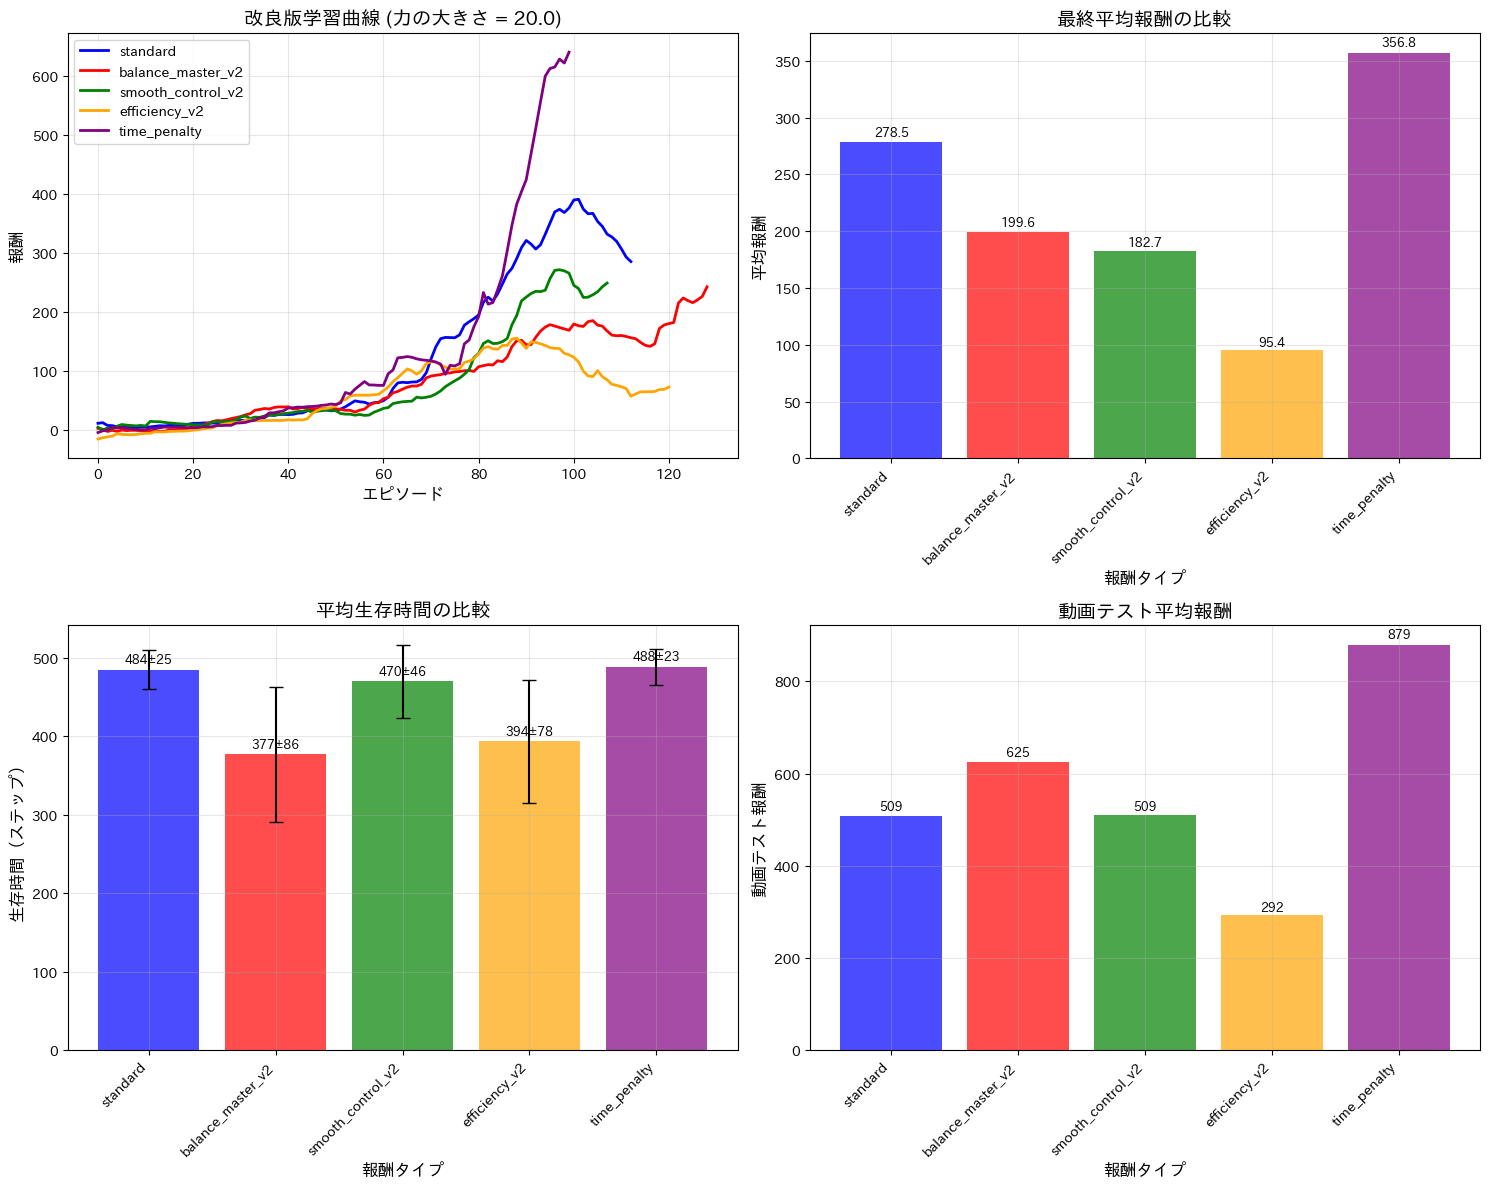


=== 最終性能の比較 ===
standard            : 報酬= 278.5, 生存時間=484.5±25.0, 動画=509.0
balance_master_v2   : 報酬= 199.6, 生存時間=376.6±85.8, 動画=625.0
smooth_control_v2   : 報酬= 182.7, 生存時間=469.8±46.4, 動画=509.3
efficiency_v2       : 報酬=  95.4, 生存時間=393.5±78.4, 動画=292.2
time_penalty        : 報酬= 356.8, 生存時間=488.2±22.7, 動画=879.4

=== 録画された動画の表示 ===

報酬タイプ 'standard' の動画:
動画ファイル: ./improved_videos/standard_force_20.0/force-20.0-standard-episode-2.mp4 (サイズ: 33174 バイト)



報酬タイプ 'balance_master_v2' の動画:
動画ファイル: ./improved_videos/balance_master_v2_force_20.0/force-20.0-balance_master_v2-episode-2.mp4 (サイズ: 28345 バイト)



報酬タイプ 'smooth_control_v2' の動画:
動画ファイル: ./improved_videos/smooth_control_v2_force_20.0/force-20.0-smooth_control_v2-episode-2.mp4 (サイズ: 33273 バイト)



報酬タイプ 'efficiency_v2' の動画:
動画ファイル: ./improved_videos/efficiency_v2_force_20.0/force-20.0-efficiency_v2-episode-2.mp4 (サイズ: 31700 バイト)



報酬タイプ 'time_penalty' の動画:
動画ファイル: ./improved_videos/time_penalty_force_20.0/force-20.0-time_penalty-episode-2.mp4 (サイズ: 32005 バイト)



=== 考察のポイント ===
1. どの報酬タイプが最も早く学習しましたか？
2. 報酬値と実際の生存時間に違いはありましたか？
3. 動画で見た制御の違いはどうでしたか？
4. 最も安定した学習を示したのはどの報酬タイプですか？
5. 実用的な観点で最も優秀だと思うのはどれですか？


In [7]:
# ============================================================================
# 【このセル = カスタム報酬の実験】  スライド ⑱⑲ に対応
#   報酬 r を自分で設計すると、エージェントの「性格(振る舞い)」が変わる。
#   5種類の報酬タイプを比較する:
#     standard          : 基準 (生存中 +1, 終端 ±10)
#     balance_master_v2 : 角度・位置の安定を最重視 (慎重)
#     smooth_control_v2 : 動きの滑らかさを重視 (急変を嫌う)
#     efficiency_v2     : 少ない動きで安定 (省エネ)
#     time_penalty      : 長時間の持続を重視
#   ★注意(スライド ⑲): 報酬タイプごとに報酬の尺度が違うので、報酬の合計では公平比較できない。
#          → 公平な比較は「生存時間」で行う(標準環境でテストする)。
# ============================================================================
# 修正版: より公平な報酬設計とearly stopping条件
import os
import glob
import base64
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
import random
from collections import deque
import matplotlib.pyplot as plt
from IPython.display import HTML
class ImprovedCustomRewardCartPoleEnv(gym.Wrapper):
    """
    改良されたカスタム報酬CartPole環境
    報酬スケールを統一し、early stopping条件を適切に設定
    """
    def __init__(self, force_mag=10.0, reward_type="standard", render_mode=None):
        env = gym.make('CartPole-v1', render_mode=render_mode)
        super().__init__(env)
        self.force_mag = force_mag
        self.reward_type = reward_type
        self.step_count = 0
        self.cumulative_angle = 0
        self.previous_state = None
        self.episode_start_time = 0

    def reset(self, **kwargs):
        self.step_count = 0
        self.cumulative_angle = 0
        self.previous_state = None
        self.episode_start_time = 0
        return super().reset(**kwargs)

    def step(self, action):
        # 力の大きさを設定
        self.env.unwrapped.force_mag = self.force_mag

        # 元の環境でステップ実行
        observation, original_reward, done, truncated, info = super().step(action)

        # カスタム報酬を計算
        custom_reward = self._calculate_custom_reward(
            observation, original_reward, done, truncated, action
        )

        self.step_count += 1
        self.previous_state = observation.copy()

        return observation, custom_reward, done, truncated, info

    # ------------------------------------------------------------------------
    # ■ スライド ⑱:  報酬関数の本体。reward_type ごとに r の計算式を切り替える。
    #   毎ステップ呼ばれ、状態(角度・位置・速度)から報酬スカラー r を返す。
    #   この r をどう設計するかで、エージェントの行動(性格)が決まる。
    # ------------------------------------------------------------------------
    def _calculate_custom_reward(self, state, original_reward, done, truncated, action):
        """改良されたカスタム報酬関数"""

        cart_position, cart_velocity, pole_angle, pole_velocity = state
        self.cumulative_angle += abs(pole_angle)

        if self.reward_type == "standard":
            # 元のコードと同じ（参考基準）
            if done or truncated:
                if self.step_count < 200:
                    return -10  # 早期終了ペナルティ
                else:
                    return 10   # 長時間生存ボーナス
            return 1  # 生存報酬

        elif self.reward_type == "balance_master_v2":
            # バランス重視（スケール調整版）
            if done or truncated:
                # 終了理由に応じたペナルティ
                if abs(pole_angle) > 0.2:  # 角度で終了
                    penalty = -20
                elif abs(cart_position) > 2.0:  # 位置で終了
                    penalty = -15
                else:
                    penalty = 5  # 時間切れ（良い）

                # 生存時間ボーナス（standardと同じスケール）
                survival_bonus = min(self.step_count / 10, 50)
                return penalty + survival_bonus
            else:
                # 生存中の報酬（1.0をベースに微調整）
                base_reward = 1.0

                # バランスボーナス（-0.5 ~ +0.5）
                balance_bonus = 0.5 * np.exp(-abs(pole_angle) * 15)

                # 位置ボーナス（-0.3 ~ +0.3）
                position_bonus = 0.3 * np.exp(-abs(cart_position) * 1.5)

                # 速度ペナルティ（0 ~ -0.3）
                velocity_penalty = -min(0.3, (abs(cart_velocity) + abs(pole_velocity)) * 0.05)

                return base_reward + balance_bonus + position_bonus + velocity_penalty

        elif self.reward_type == "smooth_control_v2":
            # 滑らかな制御（スケール調整版）
            if done or truncated:
                # 基本ペナルティ + 生存時間ボーナス
                base_penalty = -10
                survival_bonus = min(self.step_count / 10, 50)
                return base_penalty + survival_bonus
            else:
                base_reward = 1.0

                if self.previous_state is not None:
                    # 前ステップとの差分
                    prev_cart_pos, prev_cart_vel, prev_pole_angle, prev_pole_vel = self.previous_state

                    # 変化量を計算
                    position_change = abs(cart_position - prev_cart_pos)
                    velocity_change = abs(cart_velocity - prev_cart_vel)
                    angle_change = abs(pole_angle - prev_pole_angle)
                    ang_vel_change = abs(pole_velocity - prev_pole_vel)

                    # 滑らかさボーナス（変化が小さいほど高い）
                    smoothness_bonus = 0.5 * np.exp(-(position_change * 20 +
                                                    velocity_change * 5 +
                                                    angle_change * 50 +
                                                    ang_vel_change * 10))

                    return base_reward + smoothness_bonus
                else:
                    return base_reward

        elif self.reward_type == "efficiency_v2":
            # 効率重視（スケール調整版）
            if done or truncated:
                # 効率スコアを生存時間スケールに正規化
                avg_angle = self.cumulative_angle / max(self.step_count, 1)
                raw_efficiency = self.step_count / (1 + avg_angle * 100)

                # standardと同じスケールに調整
                normalized_efficiency = min(raw_efficiency * 5, 100)  # 最大100

                # 早期終了ペナルティ
                if self.step_count < 50:
                    penalty = -20
                else:
                    penalty = 0

                return normalized_efficiency + penalty
            else:
                # 生存中は小さな報酬
                return 0.5  # standardの半分

        elif self.reward_type == "time_penalty":
            # 時間効率重視（新しい報酬タイプ）
            if done or truncated:
                # 長く生存するほど高報酬だが、時間効率も考慮
                time_score = self.step_count
                angle_penalty = self.cumulative_angle * 10
                final_score = max(0, time_score - angle_penalty)

                if self.step_count < 100:
                    return -10 + final_score * 0.1
                else:
                    return final_score * 0.1
            else:
                # 角度が小さいほど高報酬
                angle_reward = max(0, 2.0 - abs(pole_angle) * 20)
                return angle_reward

        else:
            return original_reward

def train_improved_custom_agent(force_mag=10.0, reward_type="standard", episodes=500):
    """改良されたカスタム報酬でDQNエージェントを訓練"""
    print(f"力={force_mag}, 報酬タイプ={reward_type} で学習開始...")

    env = ImprovedCustomRewardCartPoleEnv(force_mag=force_mag, reward_type=reward_type)
    state_size = env.observation_space.shape[0]
    action_size = env.action_space.n

    agent = DQNAgent(state_size, action_size)
    scores = []
    scores_window = deque(maxlen=100)

    # ウォームアップ期間
    print("  ウォームアップ期間...")
    for warmup_ep in range(50):
        state, _ = env.reset()
        for step in range(200):
            action = env.action_space.sample()
            next_state, reward, done, truncated, _ = env.step(action)
            agent.remember(state, action, reward, next_state, done)
            state = next_state
            if done or truncated:
                break

    print("  本格的な学習開始...")

    for episode in range(episodes):
        state, _ = env.reset()
        total_reward = 0

        for step in range(1000):
            action = agent.act(state)
            next_state, reward, done, truncated, _ = env.step(action)

            agent.remember(state, action, reward, next_state, done)
            state = next_state
            # ★スライド ⑲:  ここでは スコア = 報酬の累計 (基本セルとは中身が違う!)
            #   基本セルのスコアは生存ステップ数だが、ここは報酬そのものの合計。
            #   報酬タイプで尺度が変わるため、この値どうしの直接比較はできない。
            total_reward += reward

            if done or truncated:
                break

        scores.append(total_reward)
        scores_window.append(total_reward)

        # 学習実行
        if len(agent.memory) > agent.batch_size:
            for _ in range(5):
                agent.replay()

        # ターゲットネットワーク更新
        if episode % agent.target_update == 0:
            agent.update_target_network()

        # 進捗表示
        if episode % 50 == 0:
            avg_score = np.mean(scores_window)
            print(f"  エピソード {episode}: 平均報酬 = {avg_score:.2f}, ε = {agent.epsilon:.3f}")

        # 統一されたearly stopping条件（生存時間ベース）
        if len(scores_window) == 100:
            avg_reward = np.mean(scores_window)

            # 実際の生存時間で評価（テスト）
            test_survival_times = []
            original_epsilon = agent.epsilon
            agent.epsilon = 0.0  # 探索なし

            for _ in range(10):
                test_state, _ = env.reset()
                survival_time = 0
                for test_step in range(1000):
                    test_action = agent.act(test_state)
                    test_state, _, test_done, test_truncated, _ = env.step(test_action)
                    survival_time += 1
                    if test_done or test_truncated:
                        break
                test_survival_times.append(survival_time)

            agent.epsilon = original_epsilon
            avg_survival = np.mean(test_survival_times)

            # 生存時間が400以上で成功とみなす
            if avg_survival >= 400:
                print(f"  エピソード {episode} で目標達成！平均生存時間: {avg_survival:.1f}")
                break

    env.close()
    final_avg_reward = np.mean(scores_window)
    print(f"  最終平均報酬: {final_avg_reward:.2f}")

    return agent, scores

def record_agent_video(agent, force_mag=10.0, reward_type="standard", video_path='./videos/', episode_count=3):
    """学習済みエージェントの動作を動画として記録"""
    print(f"  力の大きさ {force_mag}, 報酬タイプ {reward_type} の動画記録中...")

    # 動画ディレクトリを作成
    ensure_dir(video_path)

    # 既存の動画をクリア
    for file in glob.glob(f"{video_path}/*.mp4"):
        os.remove(file)

    # 動画記録用の環境を作成
    video_env = ImprovedCustomRewardCartPoleEnv(force_mag=force_mag, reward_type=reward_type, render_mode="rgb_array")
    video_env = RecordVideo(
        video_env,
        video_path,
        episode_trigger=lambda x: True,
        name_prefix=f"force-{force_mag}-{reward_type}",
        video_length=0,
        disable_logger=True
    )

    # テスト時は探索なし
    original_epsilon = agent.epsilon
    agent.epsilon = 0.0

    total_rewards = []
    for episode in range(episode_count):
        state, _ = video_env.reset()
        total_reward = 0
        step_count = 0
        max_steps = 1000

        while step_count < max_steps:
            action = agent.act(state)
            observation, reward, done, truncated, info = video_env.step(action) # Capture info
            total_reward += reward
            state = observation
            step_count += 1

            if done or truncated:
                break

        total_rewards.append(total_reward)
        print(f"    エピソード {episode+1}: 報酬 = {total_reward:.2f}, ステップ数 = {step_count}")

    # epsilonを元に戻す
    agent.epsilon = original_epsilon

    # 環境を閉じる
    try:
        video_env.close()
    except Exception as e:
        print(f"    動画環境クローズエラー: {e}")


    avg_reward = np.mean(total_rewards)
    print(f"  動画保存完了: {video_path} (平均報酬: {avg_reward:.2f})")

    # 動画ファイルの確認
    mp4_files = glob.glob(os.path.join(video_path, "*.mp4"))
    if mp4_files:
        for mp4_file in mp4_files:
            file_size = os.path.getsize(mp4_file)
            print(f"    生成された動画: {os.path.basename(mp4_file)} (サイズ: {file_size} バイト)")
    else:
        print("    警告: 動画ファイルが生成されませんでした")

    return avg_reward

def ensure_dir(directory):
    """ディレクトリが存在しない場合は作成"""
    if not os.path.exists(directory):
        os.makedirs(directory)

def show_video(video_path):
    """指定パスの動画をノートブックに表示"""
    mp4_files = sorted(glob.glob(os.path.join(video_path, "*.mp4")))
    if not mp4_files:
        print(f"エラー: {video_path} に動画ファイルが見つかりません")
        return None

    # 最新の動画ファイルを選択
    mp4_file = mp4_files[-1]

    if not os.path.exists(mp4_file):
        print(f"エラー: ファイル {mp4_file} が存在しません")
        return None

    file_size = os.path.getsize(mp4_file)
    print(f"動画ファイル: {mp4_file} (サイズ: {file_size} バイト)")

    try:
        with open(mp4_file, 'rb') as f:
            video_data = f.read()

        video_b64 = base64.b64encode(video_data).decode('ascii')
        html = f"""
        <video width="640" height="480" controls>
            <source src="data:video/mp4;base64,{video_b64}" type="video/mp4">
            お使いのブラウザは動画タグをサポートしていません。
        </video>
        """
        display(HTML(html)) # Display the HTML directly
        return HTML(html)
    except Exception as e:
        print(f"動画表示エラー: {e}")
        return None
def save_improved_results(results, force_mag, filename=None):
    """改良版実験結果をCSVファイルに保存"""
    if filename is None:
        filename = f"improved_reward_results_force_{force_mag}.csv"

    data = []
    for reward_type, result in results.items():
        scores = result['rewards']
        for episode, score in enumerate(scores):
            data.append({
                'reward_type': reward_type,
                'force': force_mag,
                'episode': episode,
                'reward': score,
                'final_avg': result['final_avg_reward'],
                'video_avg': result.get('video_avg_reward', None),
                'survival_avg': result.get('survival_avg', None)
            })

    df = pd.DataFrame(data)
    df.to_csv(filename, index=False)
    print(f"改良版結果を {filename} に保存しました")
    return df

def run_improved_experiment():
    """改良されたカスタム報酬実験"""
    print("=== 改良版カスタム報酬DQN実験 ===")
    print("目標: 統一された評価基準での公平な比較\n")

    force_mag = 20.0
    reward_types = ["standard", "balance_master_v2", "smooth_control_v2", "efficiency_v2", "time_penalty"]
    episodes = 600
    results = {}

    # 各報酬タイプで学習
    for reward_type in reward_types:
        print(f"\n{'='*60}")
        print(f"報酬タイプ: {reward_type}")
        print(f"{'='*60}")

        agent, rewards = train_improved_custom_agent(
            force_mag=force_mag,
            reward_type=reward_type,
            episodes=episodes
        )

        results[reward_type] = {
            'agent': agent,
            'rewards': rewards,
            'final_avg_reward': np.mean(rewards[-50:]) if len(rewards) > 50 else np.mean(rewards)
        }

        # 動画記録
        video_path = f"./improved_videos/{reward_type}_force_{force_mag}/"
        try:
            video_avg_reward = record_agent_video(
                agent,
                force_mag=force_mag,
                reward_type=reward_type, # Pass reward_type here
                video_path=video_path,
                episode_count=3
            )
            results[reward_type]['video_avg_reward'] = video_avg_reward
        except Exception as e:
            print(f"    動画記録エラー: {e}")
            results[reward_type]['video_avg_reward'] = None

    # 生存時間での性能評価
    print("\n=== 生存時間ベースでの最終評価 ===")
    for reward_type, result in results.items():
        agent = result['agent']

        # 生存時間テスト
        # Use the ImprovedCustomRewardCartPoleEnv for testing survival time
        # but with standard reward to get actual survival time.
        env = ImprovedCustomRewardCartPoleEnv(force_mag=force_mag, reward_type="standard")
        agent.epsilon = 0.0

        survival_times = []
        for _ in range(20):
            state, _ = env.reset()
            survival_time = 0
            for step in range(1000):
                action = agent.act(state)
                # Use the step function of the standard environment for survival time
                state, _, done, truncated, _ = env.step(action)
                survival_time += 1
                if done or truncated:
                    break
            survival_times.append(survival_time)

        env.close()
        avg_survival = np.mean(survival_times)
        std_survival = np.std(survival_times)

        print(f"{reward_type:20}: 平均生存時間 = {avg_survival:.1f} ± {std_survival:.1f}")

        # 結果に生存時間を追加
        results[reward_type]['survival_avg'] = avg_survival
        results[reward_type]['survival_std'] = std_survival

    # 結果の保存
    df = save_improved_results(results, force_mag)

    # 学習曲線の可視化
    plt.figure(figsize=(15, 12))

    # メインの学習曲線
    plt.subplot(2, 2, 1)
    colors = ['blue', 'red', 'green', 'orange', 'purple']
    window_size = 20

    for i, (reward_type, result) in enumerate(results.items()):
        rewards = result['rewards']

        # 移動平均でスムージング
        smoothed_rewards = []
        for j in range(len(rewards)):
            start_idx = max(0, j - window_size)
            smoothed_rewards.append(np.mean(rewards[start_idx:j+1]))

        plt.plot(smoothed_rewards,
                label=f'{reward_type}',
                color=colors[i],
                linewidth=2)

    plt.title(f'改良版学習曲線 (力の大きさ = {force_mag})', fontsize=14)
    plt.xlabel('エピソード', fontsize=12)
    plt.ylabel('報酬', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)

    # 最終性能比較（報酬）
    plt.subplot(2, 2, 2)
    reward_types_list = list(results.keys())
    final_rewards = [results[rt]['final_avg_reward'] for rt in reward_types_list]

    bars1 = plt.bar(range(len(reward_types_list)), final_rewards,
                   color=colors[:len(reward_types_list)], alpha=0.7)
    plt.title('最終平均報酬の比較', fontsize=14)
    plt.xlabel('報酬タイプ', fontsize=12)
    plt.ylabel('平均報酬', fontsize=12)
    plt.xticks(range(len(reward_types_list)), reward_types_list, rotation=45, ha='right')
    plt.grid(True, alpha=0.3)

    # 値をバーの上に表示
    for i, bar in enumerate(bars1):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9)

    # 生存時間比較
    plt.subplot(2, 2, 3)
    survival_avgs = [results[rt]['survival_avg'] for rt in reward_types_list]
    survival_stds = [results[rt]['survival_std'] for rt in reward_types_list]

    bars2 = plt.bar(range(len(reward_types_list)), survival_avgs,
                   yerr=survival_stds, color=colors[:len(reward_types_list)],
                   alpha=0.7, capsize=5)
    plt.title('平均生存時間の比較', fontsize=14)
    plt.xlabel('報酬タイプ', fontsize=12)
    plt.ylabel('生存時間（ステップ）', fontsize=12)
    plt.xticks(range(len(reward_types_list)), reward_types_list, rotation=45, ha='right')
    plt.grid(True, alpha=0.3)

    # 値をバーの上に表示
    for i, bar in enumerate(bars2):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                f'{height:.0f}±{survival_stds[i]:.0f}',
                ha='center', va='bottom', fontsize=9)

    # 動画テスト結果
    plt.subplot(2, 2, 4)
    # Handle None values in video_avg_reward by replacing them with 0 for plotting
    video_rewards = [results[rt].get('video_avg_reward', 0) for rt in reward_types_list]


    bars3 = plt.bar(range(len(reward_types_list)), video_rewards,
                   color=colors[:len(reward_types_list)], alpha=0.7)
    plt.title('動画テスト平均報酬', fontsize=14)
    plt.xlabel('報酬タイプ', fontsize=12)
    plt.ylabel('動画テスト報酬', fontsize=12)
    plt.xticks(range(len(reward_types_list)), reward_types_list, rotation=45, ha='right')
    plt.grid(True, alpha=0.3)

    # 値をバーの上に表示
    for i, bar in enumerate(bars3):
        height = bar.get_height()
        if height > 0: # Only display text if height is greater than 0
            plt.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                    f'{height:.0f}', ha='center', va='bottom', fontsize=9)


    plt.tight_layout()

    # グラフを保存
    graph_filename = f'improved_reward_analysis_force_{force_mag}.png'
    plt.savefig(graph_filename, dpi=300, bbox_inches='tight')
    print(f"分析グラフを {graph_filename} に保存しました")
    plt.show()

    # 最終性能の比較サマリー
    print("\n=== 最終性能の比較 ===")
    for reward_type, result in results.items():
        print(f"{reward_type:20}: 報酬={result['final_avg_reward']:6.1f}, "
              f"生存時間={result['survival_avg']:5.1f}±{result['survival_std']:4.1f}, "
              f"動画={result.get('video_avg_reward', 0):5.1f}") # Handle None in print

    # 動画の表示
    print("\n=== 録画された動画の表示 ===")
    for reward_type in reward_types:
        video_path = f"./improved_videos/{reward_type}_force_{force_mag}/"
        print(f"\n報酬タイプ '{reward_type}' の動画:")
        show_video(video_path)  # あなたの既存関数を使用

    # 考察のポイント
    print("\n=== 考察のポイント ===")
    print("1. どの報酬タイプが最も早く学習しましたか？")
    print("2. 報酬値と実際の生存時間に違いはありましたか？")
    print("3. 動画で見た制御の違いはどうでしたか？")
    print("4. 最も安定した学習を示したのはどの報酬タイプですか？")
    print("5. 実用的な観点で最も優秀だと思うのはどれですか？")


    return results

# 使用例
if __name__ == "__main__":
    improved_results = run_improved_experiment()

人工知能による解説

📊 3つの棒グラフの意味
1. 右上: 最終平均報酬の比較

意味: 学習終了時の最後50エピソードの平均報酬

問題: 報酬タイプごとにスケールが違うので比較が困難

なぜ重要: 各報酬関数での「学習の収束具合」がわかる

2. 左下: 平均生存時間の比較 ⭐

意味: 学習後のエージェントが実際に何ステップ生存できるか

重要: これが最も客観的で公平な性能指標！

例: 全て同じ環境（standard）で生存時間をテスト

エラーバー: 20回テストのばらつき（安定性を示す）

3. 右下: 動画テスト平均報酬


意味: 動画記録時（3エピソード）の報酬の平均

特徴: 各エージェントが自分の報酬関数で評価される

注意: 報酬スケールが違うので直接比較は難しい

🎯 どれが最も重要？

答え: 左下の「平均生存時間」が最重要！

## 結果は　improved_videos　というフォルダの下に格納される。
CSVとPNGも生成される。

CSVに保存されるデータ
- reward_type: 報酬タイプ
- episode: エピソード番号  
- reward: そのエピソードの報酬
- final_avg: 最終平均報酬
- video_avg: 動画テスト平均報酬
- survival_avg: 生存時間テスト平均

## 人工知能による解説

balance_master_v2

動き: 小刻みで慎重
特徴: ポールが少し傾いただけで即座に修正
弱点: 過度に慎重で、大きな外乱に対応できない可能性

smooth_control_v2

動き: 流れるような美しい軌道
特徴: 急激な変化を避け、予測的に動く
弱点: 緊急時の対応が遅れる可能性

efficiency_v2

動き: 必要最小限の動作
特徴: 無駄を省いた効率的な制御
弱点: 安全マージンが小さく、ギリギリの制御

time_penalty

動き: 持続可能な安定制御
特徴: 多少の揺れは許容し、長期安定を優先
弱点: 短期的な精度は劣る可能性

実際に動画を見ると、これらの「性格の違い」が視覚的に確認できるはずです。どの報酬が最も効果的か、とても楽しみですね。

🎯 4つのカスタム報酬タイプの解説
1. balance_master_v2 - バランス重視エージェント
🎪 サーカスの綱渡り師のような学習
python# 考え方：「ポールをまっすぐ立てることが最重要！」
base_reward = 1.0  # 基本生存点
balance_bonus = 0.5 * exp(-角度 * 15)  # 角度が小さいほど高得点
position_bonus = 0.3 * exp(-位置 * 1.5)  # 中央にいるほど高得点
velocity_penalty = -速度 * 0.05  # 激しく動くとペナルティ
特徴：

ポールの角度が少しでも傾くと大幅減点
カートが中央から離れるとペナルティ
急激な動きを嫌い、安定性を重視

期待される行動：

非常に慎重で安定した制御
小さな修正動作を頻繁に行う
「転ばぬ先の杖」的な予防的制御


2. smooth_control_v2 - スムース制御エージェント
🏎️ F1ドライバーのような学習
python# 考え方：「急ハンドル・急ブレーキは禁止！滑らかに操縦せよ」
base_reward = 1.0
smoothness_bonus = 0.5 * exp(-(位置変化*20 + 速度変化*5 + 角度変化*50))
特徴：

前のステップからの変化量を重視
急激な方向転換や速度変化にペナルティ
連続性・一貫性を評価

期待される行動：

なめらかで流れるような制御
予測的な動き（急に止まらない）
エレガントで美しい軌道


3. efficiency_v2 - 効率重視エージェント
⚡ 省エネ家電のような学習
python# 考え方：「最小の努力で最大の効果を！」
efficiency_score = 生存時間 / (1 + 平均角度偏差 * 100)
normalized_efficiency = min(efficiency_score * 5, 100)
特徴：

生存時間だけでなく、どれだけ安定していたかも評価
長時間生きても、ずっとフラフラしていたら低評価
短時間でも非常に安定していれば高評価

期待される行動：

無駄な動きを排除
最短距離での復帰動作
エネルギー効率の良い制御


4. time_penalty - 時間効率重視エージェント
🏃 マラソンランナーのような学習
python# 考え方：「長く走り続けるが、フォームも大切！」
time_score = 生存ステップ数
angle_penalty = 累積角度偏差 * 10
final_score = max(0, time_score - angle_penalty)
特徴：

長期間生存することを重視
ただし、姿勢が悪い（角度が大きい）と減点
持久力と安定性の両立を求める

期待される行動：

長期戦略を重視
短期的な安定より長期的な持続性
多少の揺れは許容するが、大きな傾きは避ける